## Part 1:  How do we turn a sentence into a row of numbers?

In [1]:
import pandas as pd
import numpy as np
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

from torch import nn

In [2]:
data = pd.read_csv('data/train.csv')
data.head(10)


,id,sentence,label
0,fde9e435-8186-4cb3-8ec1-1be67ddb5f96,"""Трудно е класически оркестър и рок банда да с...",OBJ
1,bb522430-40f0-4781-9910-92a1aefd013b,"Следователно, Москва е пазителка на православн...",OBJ
2,d6a84f01-9153-4f3b-bca6-ed2b2edc6a9e,От Washington Post са изготвили подробен матер...,OBJ
3,3623488a-c528-4509-a92d-9ad4b49099ec,И пак така относно заслугите за постигнатото о...,OBJ
4,587b0e27-6ac8-433f-9b99-adf8d9c7c0a2,Понякога удобството да разтвориш набързо стран...,OBJ
5,f2d2aab0-25af-4bef-b678-badd5b390e8d,"Вчера Барак Обама, отиващият си тъжен стопанин...",SUBJ
6,f94840f8-7fb6-42e3-aa84-0a250d58af5b,Дали защото Първият черен президент на САЩ си ...,SUBJ
7,b30bd670-07fd-40ac-82d7-c67988f57cc3,"И като доказателство за това, гръмна и следващ...",SUBJ
8,512b57e5-9b65-43a8-8dec-01bef61a3ad6,"Последният път, когато Америка се обърна навът...",SUBJ
9,d6bad64f-59f2-491e-9d99-103d2748d647,"Шок, бомба, ужас!",SUBJ


In [3]:
data['sentence'] = data['sentence'].str.lower()
data['label'] = [1 if el == 'OBJ' else 0 for el in data['label']]
data.head(10)

,id,sentence,label
0,fde9e435-8186-4cb3-8ec1-1be67ddb5f96,"""трудно е класически оркестър и рок банда да с...",1
1,bb522430-40f0-4781-9910-92a1aefd013b,"следователно, москва е пазителка на православн...",1
2,d6a84f01-9153-4f3b-bca6-ed2b2edc6a9e,от washington post са изготвили подробен матер...,1
3,3623488a-c528-4509-a92d-9ad4b49099ec,и пак така относно заслугите за постигнатото о...,1
4,587b0e27-6ac8-433f-9b99-adf8d9c7c0a2,понякога удобството да разтвориш набързо стран...,1
5,f2d2aab0-25af-4bef-b678-badd5b390e8d,"вчера барак обама, отиващият си тъжен стопанин...",0
6,f94840f8-7fb6-42e3-aa84-0a250d58af5b,дали защото първият черен президент на сащ си ...,0
7,b30bd670-07fd-40ac-82d7-c67988f57cc3,"и като доказателство за това, гръмна и следващ...",0
8,512b57e5-9b65-43a8-8dec-01bef61a3ad6,"последният път, когато америка се обърна навът...",0
9,d6bad64f-59f2-491e-9d99-103d2748d647,"шок, бомба, ужас!",0


#### We want to test how an algorithm predicts subjectivity. How do we do that ?

In [4]:
vectorizer = TfidfVectorizer(max_features=4000)
X_train, X_test, y_train, y_test = train_test_split(data['sentence'], data['label'],test_size=0.2)

In [5]:
print(y_train)

160    0
709    0
144    1
197    0
716    0
      ..
675    1
422    0
145    0
758    1
2      1
Name: label, Length: 640, dtype: int64


In [6]:
print(y_train.values)

[0 0 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 0 1 0 0 1 1 0 0 0 1 1 0 1 0 1 1 0 0 0 1
 0 1 0 0 1 1 1 0 1 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 1 1 0
 1 0 1 0 0 1 0 1 1 1 1 0 0 0 1 0 1 0 1 1 0 0 0 0 1 0 0 1 0 0 0 0 1 1 1 0 0
 0 0 1 0 1 1 1 0 1 0 1 1 1 1 1 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0 1 1 0 0 1 1 1
 1 1 0 1 1 0 1 0 1 1 1 1 0 1 0 1 1 0 1 0 1 1 0 1 0 0 0 1 1 1 1 0 0 0 0 1 0
 1 1 1 0 0 0 1 1 0 1 0 1 1 0 1 0 1 0 0 0 0 0 0 1 0 1 1 0 1 1 0 1 0 1 0 0 0
 1 0 0 0 1 0 1 1 0 1 0 1 1 1 1 0 1 0 0 1 0 1 0 1 1 0 1 1 0 1 1 1 1 0 1 1 0
 1 0 0 0 1 1 1 1 1 0 0 1 0 1 0 0 0 1 1 0 1 0 1 0 1 0 0 1 0 1 1 0 1 1 0 1 1
 1 0 0 1 1 0 1 1 0 0 1 0 1 0 1 1 1 0 0 0 1 0 1 0 0 1 1 0 1 1 1 1 1 1 0 1 1
 1 1 0 1 1 0 1 1 0 1 1 0 1 1 0 1 1 0 0 1 0 0 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1
 1 0 1 1 0 1 1 0 0 0 1 0 1 0 1 0 1 1 1 0 0 0 1 1 1 1 1 0 0 1 1 1 1 0 0 1 1
 1 1 0 0 0 1 0 0 1 0 1 1 1 1 1 0 1 0 0 0 1 0 1 1 1 0 1 1 1 0 1 0 0 1 1 1 1
 1 1 1 0 1 1 1 1 1 1 0 0 1 1 0 1 1 0 1 0 0 0 1 0 1 0 0 1 0 1 1 0 0 1 0 1 1
 0 0 1 0 1 1 0 1 1 1 1 0 

In [7]:
print(y_train.values.reshape(-1,1).astype(np.float32))

[[0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.

In [8]:
X_train_tfidf = vectorizer.fit_transform(X_train).toarray().astype(np.float32)
X_test_tfidf  = vectorizer.transform(X_test).toarray().astype(np.float32)
y_train_np = y_train.values.reshape(-1,1).astype(np.float32)
y_test_np  = y_test.values.reshape(-1,1).astype(np.float32)

In [9]:
X_train_tfidf.shape

(640, 4000)

In [10]:
type(y_train_np)

numpy.ndarray

In [11]:
class SubjectivityDataset(Dataset):
  def __init__(self, X, y):
    self.X = X
    self.y = y
  def __len__(self):
    return len(self.X)

  def __getitem__(self,idx):
    return self.X[idx], self.y[idx]

In [12]:
train_dataset = SubjectivityDataset(X_train_tfidf, y_train_np)
test_dataset  = SubjectivityDataset(X_test_tfidf,  y_test_np)

In [13]:
class LinearClassifier(nn.Module):
  def __init__(self, features_size, num_classes):
    super(LinearClassifier, self).__init__()
    self.linear  = nn.Linear(features_size, num_classes)
    self.sigmoid = nn.Sigmoid()
  def forward(self, x):
    return self.sigmoid(self.linear(x))

In [14]:
model = LinearClassifier(X_train_tfidf.shape[1], 1)

In [15]:
sgd = torch.optim.SGD(model.parameters(), lr=0.001)
bce = nn.BCELoss()  # -> Why this loss function?

In [16]:
EPOCHS     = 5
BATCH_SIZE = 16

def train(model, optimizer, loss_fn, dataset):
  model.train()
  for epoch in range(EPOCHS + 1):
    cost = []
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    for X, y in tqdm(dataloader):
      optimizer.zero_grad()
      preds = model(X)
      loss  = loss_fn(preds, y)
      loss.backward()
      optimizer.step()
      cost.append(loss.detach().cpu().item())
    print("Epoch: {:04d} cost={:.9f}".format(epoch, np.mean(cost)))

def evaluate(model, dataset):
  model.eval()
  correct = total = 0
  with torch.no_grad():
    for X, y in DataLoader(dataset, batch_size=64):
      preds   = (model(X) > 0.5).float()
      correct += (preds == y).sum().item()
      total   += len(y)
  print(f"Accuracy: {correct/total:.4f}")

In [17]:
train(model, sgd, bce, train_dataset)
evaluate(model, test_dataset)

100%|██████████| 40/40 [00:00<00:00, 476.14it/s]


Epoch: 0000 cost=0.693894809


100%|██████████| 40/40 [00:00<00:00, 1106.07it/s]


Epoch: 0001 cost=0.693781655


100%|██████████| 40/40 [00:00<00:00, 1218.45it/s]


...

Epoch: 0003 cost=0.693566534


100%|██████████| 40/40 [00:00<00:00, 1110.08it/s]


Epoch: 0004 cost=0.693460710


100%|██████████| 40/40 [00:00<00:00, 1072.79it/s]

Epoch: 0005 cost=0.693359897
Accuracy: 0.5155


## Is this accuracy considered good ? How would we know ?

---

In [ ]:
y_train_np.mean()

1


In [21]:
majority_class = round(y_train_np.mean())           # 0 or 1, whichever is more common
baseline_acc   = (y_test_np == majority_class).mean()
print(f"Majority class: {majority_class}  →  Baseline accuracy: {baseline_acc:.4f}")

Majority class: 1  →  Baseline accuracy: 0.5714


## This would be the minimum effort to quickly run and see results for our task. But is it enough ?
### We want to go beyond running a single algorithm and getting results, we want to see how we can improve the performance on our task without changing to another architecture

---
# Part 2: Feature Engineering

So far we let TF-IDF decide what "features" a sentence has. But we know things about language that a simple bag-of-words misses. Feature engineering is the process of encoding that knowledge manually — turning human intuitions into numbers the model can use.

There are two strategies:
- **Manual** — you design features by hand based on domain knowledge.
- **Automatic** — you let a statistical method measure which features are most informative, then keep only those.

## 2a. Manual Feature Engineering

Subjective sentences often *feel* different from objective ones. Think about:
- They tend to use more **exclamation marks and question marks** (emotional punctuation).
- They tend to be **shorter** — a quick opinion vs. a factual report.

These are our two hand-crafted features.

In [23]:
import re

def manual_features(sentences):
    """Returns a (N, 2) array with:
       col 0 - number of exclamation/question marks
       col 1 - sentence length in tokens
    """
    feats = []
    for s in sentences:
        punct_count = len(re.findall(r'[!?]', s))
        word_count  = len(s.split())
        feats.append([punct_count, word_count])
    return np.array(feats, dtype=np.float32)

X_train_manual = manual_features(X_train)
X_test_manual  = manual_features(X_test)
print("Manual feature matrix shape:", X_train_manual.shape)
print("Sample rows:\n", X_train_manual[:10])

Manual feature matrix shape: (640, 2)
Sample rows:
 [[ 0. 18.]
 [ 0. 30.]
 [ 0. 40.]
 [ 0. 17.]
 [ 0. 65.]
 [ 0. 42.]
 [ 0. 28.]
 [ 0. 15.]
 [ 0. 31.]
 [ 1.  7.]]


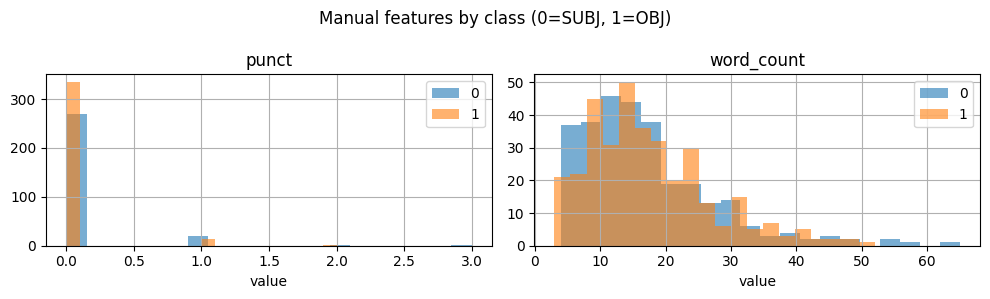

In [26]:
# Quick sanity check: do these features differ between classes?
import matplotlib.pyplot as plt


df_feat = pd.DataFrame(X_train_manual, columns=['punct', 'word_count'])
df_feat['label'] = y_train.values

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, col in zip(axes, ['punct', 'word_count']):
    df_feat.groupby('label')[col].hist(ax=ax, alpha=0.6, bins=20, legend=True)
    ax.set_title(col)
    ax.set_xlabel('value')
plt.suptitle('Manual features by class (0=SUBJ, 1=OBJ)')
plt.tight_layout()
plt.show()

In [27]:
# Train the same linear model using ONLY the 2 manual features
train_manual = SubjectivityDataset(X_train_manual, y_train_np)
test_manual  = SubjectivityDataset(X_test_manual,  y_test_np)

model_manual = LinearClassifier(2, 1)
train(model_manual, torch.optim.SGD(model_manual.parameters(), lr=0.01), bce, train_manual)
evaluate(model_manual, test_manual)

100%|██████████| 40/40 [00:00<00:00, 1841.87it/s]


Epoch: 0000 cost=0.723222911


100%|██████████| 40/40 [00:00<00:00, 2668.13it/s]


Epoch: 0001 cost=0.711909065


100%|██████████| 40/40 [00:00<00:00, 2466.40it/s]


...

Epoch: 0003 cost=0.715348195


100%|██████████| 40/40 [00:00<00:00, 1932.53it/s]


Epoch: 0004 cost=0.717730770


100%|██████████| 40/40 [00:00<00:00, 1698.56it/s]

Epoch: 0005 cost=0.711221868
Accuracy: 0.6211


> **Discussion:** The accuracy here is likely higher than TF-IDF — we've thrown away most of the vocabulary signal. But notice that *2 numbers* got us somewhere reasonable. This illustrates that good feature engineering can matter a lot, especially when you don't have much data.

We can also **combine** our manual features with TF-IDF to potentially get the best of both worlds:

In [28]:
# Concatenate TF-IDF + manual features
X_train_combined = np.hstack([X_train_tfidf, X_train_manual])
X_test_combined  = np.hstack([X_test_tfidf,  X_test_manual])
print("Combined shape:", X_train_combined.shape)  # 640 x 4002

train_combined = SubjectivityDataset(X_train_combined, y_train_np)
test_combined  = SubjectivityDataset(X_test_combined,  y_test_np)

model_combined = LinearClassifier(X_train_combined.shape[1], 1)
train(model_combined, torch.optim.SGD(model_combined.parameters(), lr=0.001), bce, train_combined)
evaluate(model_combined, test_combined)

Combined shape: (640, 4002)


100%|██████████| 40/40 [00:00<00:00, 1176.05it/s]


Epoch: 0000 cost=0.691430928


100%|██████████| 40/40 [00:00<00:00, 1116.10it/s]


Epoch: 0001 cost=0.691927752


...

Epoch: 0003 cost=0.691610023


100%|██████████| 40/40 [00:00<00:00, 1148.40it/s]


Epoch: 0004 cost=0.692212509


100%|██████████| 40/40 [00:00<00:00, 1059.56it/s]

Epoch: 0005 cost=0.691853869
Accuracy: 0.5714


---
## 2b. Automatic Feature Selection

TF-IDF gives us 4000 features, but most tokens are probably noise. **Feature selection** asks: which of these 4000 features actually carry signal for our classification task?

We'll rank every token by four metrics, then compare a model trained on **all** features vs. one trained on only the **top-K** most informative ones.

### Token Importance Metrics

1. Inverse Document Frequency (IDF) 

    * IDF measures how informative a token is based on how rare it is across the entire corpus.

2. Chi-Squared 

    * ($\chi^2$)This metric tests the statistical independence between a token $t$ and a class $c$. It answers: Is the presence of this word significantly related to the target class, or is it just a coincidence?
    $$\chi^2_{avg}(t) = \sum{P(c_i) \cdot \chi^2(c_i, t)}$$

3. Information Gain (IG) 
    * Information Gain measures the reduction in entropy (uncertainty). It tells us how much knowing the presence or absence of a token helps us predict the class.
$$G(t) = -\sum{P(c_i) \log{P(c_i)}} + P(t)\sum{P(c_i|t) \log{P(c_i|t)}} + P(\neg{t})\sum{P(c_i|\neg{t}) \log{P(c_i|\neg{t})}}$$

4. Mutual Information (MI)
    * Mutual Information quantifies the amount of information (in bits) obtained about one random variable (the class) through observing another (the token).
    $$MI(t,c) = \log{\frac{P(t,c)}{P(t)P(c)}} = \log{P(t|c)} - \log{P(t)}$$

| Metric | What it measures |
|---|---|
| **IDF** | How rare a token is across all documents — rare tokens are more specific |
| **Chi²** | Statistical dependence between a token and the class label |
| **Information Gain** | How much the presence/absence of a token reduces class uncertainty |
| **Mutual Information** | How many "bits" a token tells us about the class |




In [29]:
# We compute all four metrics in one pass over the vocabulary.
# Inputs: the fitted vectorizer, the binary presence matrix, and the labels.

vocab    = np.array(vectorizer.get_feature_names_out())   # (V,)
idf_vals = vectorizer.idf_                                 # (V,) — free from the vectorizer
X_bin    = (X_train_tfidf > 0).astype(float)              # binary presence: (N, V)
y_flat   = y_train_np.ravel()                              # (N,)

classes, counts = np.unique(y_flat, return_counts=True)
N   = len(y_flat)
P_c = counts / N
H_C = -np.sum(P_c * np.log2(P_c + 1e-12))                 

chi2_scores = np.zeros(len(vocab))
ig_scores   = np.zeros(len(vocab))
mi_scores   = np.zeros(len(vocab))

for j in range(len(vocab)):
    t  = X_bin[:, j]
    nt = 1 - t
    P_t  = t.mean()
    P_nt = 1 - P_t

    chi2_t = ig_t = mi_t = 0.0
    for c, p_ci in zip(classes, P_c):
        in_c = (y_flat == c).astype(float)
        A = (t  * in_c     ).sum()   # present  & in class
        B = (t  * (1-in_c) ).sum()   # present  & not in class
        C = (nt * in_c     ).sum()   # absent   & in class
        D = (nt * (1-in_c) ).sum()   # absent   & not in class

        for O, E_num, E_den in [(A,(A+B)*(A+C),N),(B,(A+B)*(B+D),N),
                                (C,(C+D)*(A+C),N),(D,(C+D)*(B+D),N)]:
            E = E_num / (E_den + 1e-12)
            chi2_t += p_ci * (O - E)**2 / (E + 1e-12)

        P_ci_t  = A / (A + B + 1e-12)
        P_ci_nt = C / (C + D + 1e-12)
        ig_t += (P_t  * P_ci_t  * np.log2(P_ci_t  + 1e-12) +
                 P_nt * P_ci_nt * np.log2(P_ci_nt + 1e-12))

        mi_t += p_ci * np.log2((A/N) / (P_t * p_ci + 1e-12) + 1e-12)

    chi2_scores[j] = chi2_t
    ig_scores[j]   = H_C + ig_t
    mi_scores[j]   = mi_t

df_importance = pd.DataFrame(
    {'IDF': idf_vals, 'Chi2': chi2_scores, 'InfoGain': ig_scores, 'MutualInfo': mi_scores},
    index=vocab
)
df_importance.sort_values('Chi2', ascending=False).head(15)

,IDF,Chi2,InfoGain,MutualInfo
не,2.595495,19.189761,0.021652,-0.087377
да,2.051383,13.741714,0.015483,-0.028865
може,4.029042,12.225294,0.014206,-0.322046
той,3.749457,11.293130,0.013774,-0.239958
нещо,5.065134,8.063322,0.010108,-0.881180
ако,4.029042,7.538041,0.008596,-0.184779
според,4.629816,7.258134,0.009381,-0.479031
добре,5.160444,6.887190,0.008557,-0.806705
нищо,5.160444,6.887190,0.008557,-0.806705
абсолютно,5.671270,6.005825,0.008897,-21.159059


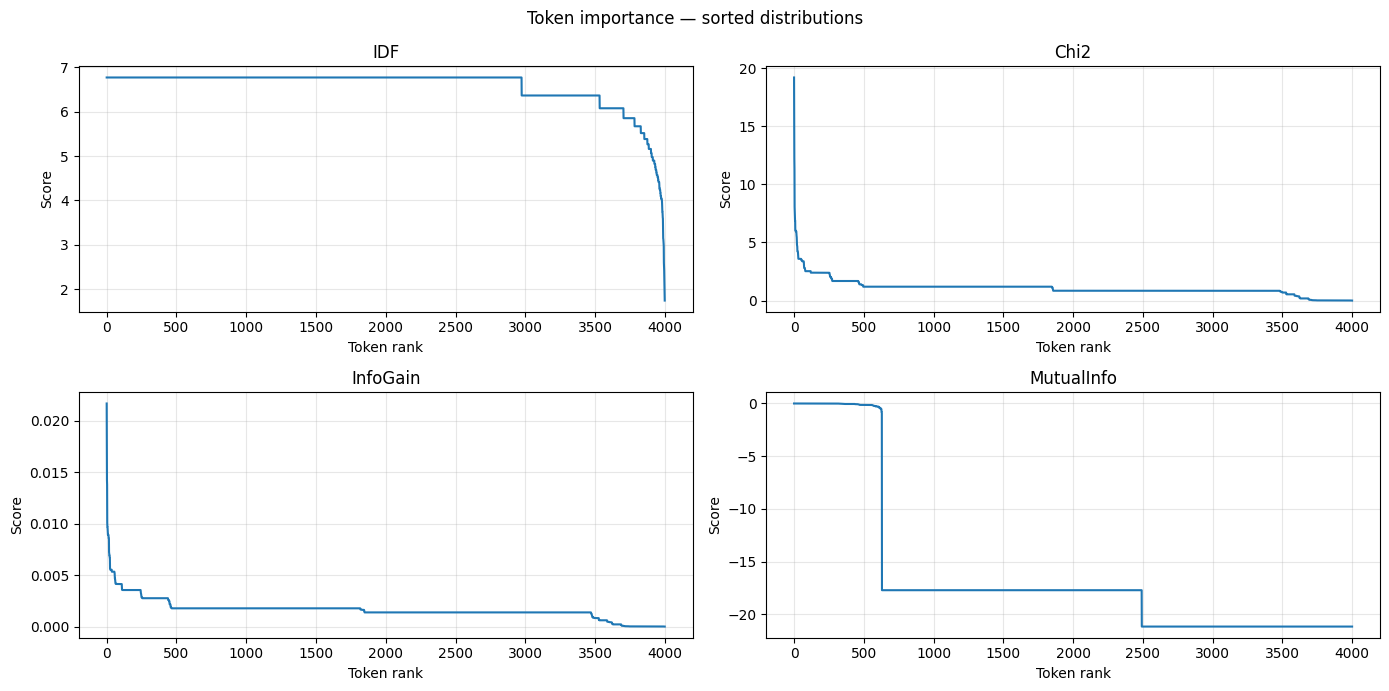

In [30]:
# Visualise the sorted distributions — look for the "elbow" to choose your cutoff K
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for ax, col in zip(axes.flat, ['IDF', 'Chi2', 'InfoGain', 'MutualInfo']):
    ax.plot(df_importance[col].sort_values(ascending=False).values)
    ax.set_title(col)
    ax.set_xlabel('Token rank')
    ax.set_ylabel('Score')
    ax.grid(True, alpha=0.3)
plt.suptitle('Token importance — sorted distributions')
plt.tight_layout()
plt.show()

In [53]:
# Select the top-K tokens by Chi2 and retrain — does fewer features hurt?
K = 1000
top_k_idx = df_importance['Chi2'].nlargest(K).index   # token strings
# Map back to column indices in X_train_tfidf
vocab_list  = list(vocab)
top_k_cols  = [vocab_list.index(t) for t in top_k_idx]

X_train_sel = X_train_tfidf[:, top_k_cols]
X_test_sel  = X_test_tfidf[:,  top_k_cols]
print(f"Reduced feature matrix: {X_train_sel.shape}  (was {X_train_tfidf.shape})")

train_sel = SubjectivityDataset(X_train_sel, y_train_np)
test_sel  = SubjectivityDataset(X_test_sel,  y_test_np)

model_sel = LinearClassifier(K, 1)
train(model_sel, torch.optim.SGD(model_sel.parameters(), lr=0.001), bce, train_sel)
evaluate(model_sel, test_sel)

Reduced feature matrix: (640, 1000)  (was (640, 4000))


100%|██████████| 40/40 [00:00<00:00, 2336.27it/s]


Epoch: 0000 cost=0.692518176


100%|██████████| 40/40 [00:00<00:00, 2151.61it/s]


Epoch: 0001 cost=0.692442690


...

Epoch: 0003 cost=0.692297544


100%|██████████| 40/40 [00:00<00:00, 1801.23it/s]


Epoch: 0004 cost=0.692228404


100%|██████████| 40/40 [00:00<00:00, 2353.97it/s]

Epoch: 0005 cost=0.692158069
Accuracy: 0.5590


> **Discussion:** With only ~12% of the original features we often get *comparable or better* accuracy. Fewer features means:
> - Faster training
> - Less overfitting
> - A model whose weights are easier to interpret
>
> Try changing `K` and watch what happens. There's usually a sweet-spot around the elbow of the Chi² curve.